Let's say you have a trend you are trying to model that you know to be monotonically increasing or decreasing; this could be something like default as a function of risk, power usage as a function of temperature, or CO2 emissions over time. [Generalized Additive Models](http://statmills.com/2023-11-20-Penalized_Splines_Using_glum/) are a great general purpose modeling tool that you could use to model these relationships. It turns out that there are variations of GAMs that allow for enforcing a constraint on a spline curve; Penalized-splines (P-splines) and Shape Constrained Additive Models (SCAM). This contraint could be an always increasing or decreasing function, or even a convex or concave shape. P-splines use a penalty matrix to enfore the constraint by penalizing differences between neighboring coefficients. SCAMs use a different parameterization of a GAM that I wanted to learn more about. This blog post is an attempt to recreate the logic in the [SCAM paper](https://www.researchgate.net/publication/271740857_Shape_constrained_additive_models) using python and JAX. If you wanted to use these models for real there is an [R-package for SCAMs](https://cran.r-project.org/web/packages/scam/index.html) and a P-spline implementation in python using the [pygam library](https://pygam.readthedocs.io/en/latest/api/api.html#spline-term).

### Shape Constrained What-now?

Shape Constrained Additive Models :) SCAMs use a reparameterization of a traditional B-spline basis to enforce a constraint. If you want a refresher on B-Splines and GAMs I wrote an [introductory focused post](http://statmills.com/2023-11-20-Penalized_Splines_Using_glum/) last year. This new expression of the B-spline basis has two components:
1. A transformation on the coefficients of a traditional B-spline to ensure they are always positive
2. A constraint matrix inserted in the $\mathbf{X} \mathbf{\beta}$ multiplication. 

A traditional B-spline can be expressed as 

$$
\hat{Y} = \mathbf{X}\mathbf{\beta}
$$

Where $\mathbf{X}$ is the $n$ by $j$ spline-transformed data matrix and $\mathbf{\beta}$ are the $j$ coefficients found from fitting a model to the data. If we don't impose any constraints or penalties this could just be fit as a standard GLM. But now we want to force the curve to either always go up, or always go down. 

The first step of the reparameterization is simple enough, we apply the exponential function to our unconstrained coefficients:

$$
\tilde{\beta} = \exp(\beta)
$$

Now each transformed coefficient is stricly positive. We'll see the reason for this below. 

The constraint matrix combines these transformed coefficients so that the desired constraint is adhered to. We'll walk through how this works for a decreasing trend. We know our transformed coefficients are strictly positive. So if we want our curve to always decrease, then each successive coefficient we multiply with our $X$ matrix needs to be strictly smaller than the previous coefficient. We can accomplish this by apply another reparameterization to our coefficients. Lets set the first coefficient in our new coefficient vector to be the first transformed coefficient. The next coefficient now needs to be less than this first value. One way to do that is to subtract our $\tilde{\beta_2}$ value from $\tilde{\beta_1}$ and use the result as the 2nd transformed coefficient. Since we know $\tilde{\beta_2}$ is positive (from using the exponential function) then we know that $\beta_1$ is strictly larger than $\tilde{\beta_1} - \tilde{\beta_2}$. We can repeat this logic the whole way down our vector of coefficients:

$$
\begin{equation}
\overline{\beta_1} = \tilde{\beta_1} \\
\overline{\beta_2} = \tilde{\beta_1} - \tilde{\beta_2} \\
\overline{\beta_3} = \tilde{\beta_1} - \tilde{\beta_2} - \tilde{\beta_3} \\
\dots
\end{equation}
$$

We don't have to write these equations out by hand, we can leverage a lower triangle matrix where all values are negative 1 except the first column.

$$
\mathbf{\overline{\beta}} =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
1 & -1 & 0 & 0 \\
1 & -1 & -1 & 0 \\
1 & -1 & -1 & -1 \\
\end{bmatrix}
\mathbf{\tilde{\beta}}
$$

The SCAM paper doesn't create this 2nd intermediate coefficient vector $\mathbf{\overline{\beta}}$ but instead just includes the constraint matrix $\mathbf{Sigma}$ in the prediction matrix multiplication:

$$
\hat{Y} = \mathbf{X} \mathbf{\Sigma} \mathbf{\tilde{\beta}}
$$

To summarize the process we first start with unconstrained coefficients that we transform into positive numbers. Then we combine them in a way so that the resulting coefficients on each input column in $\mathbf{X}$ are decreasing as we move along the coefficients. Then we multiply those values by the basis matrix to generate our predictions. 

### Comparison with P-splines

P-splines enforce a monotonic constraint using a penalty matrix instead of a constraint matrix. This penalty matrix punishes any difference between neighboring coefficients that goes against this desired trend. So a positive value for $\beta_{i+1} - \beta_i$ would contribute a penalty to the loss function of the model using the P-spline, while a negative value would not contribute anything. If I have time for another post I'll do a more thorough comparison to see how the differences actually manifest in model fitting between the two methods.

### An Example: Japanese Cherry Blossom Data

There is a phenomenal dataset of the first day of the Cherry Blossoms blooming in the Japanese Royal Gardens every year. I want to estimate the long-term trend of this date moving up over time due to Global Warming. There are natural, short-term fluctuations in this data based on the local climate in Japan so an accurate model of the year to year fluctuations will not be monotonically decreasing. For this post I'm only interested in the long-term trend which I'm going to assume only goes one way. We'll read in some data and build our model. I'm only going to show some code cells and output, but if you want to see the full code it is available on my github.

In [7]:
import numpy as np
import jax.numpy as jnp
import jax

import polars as pl
from plotnine import *
from sklearn.preprocessing import SplineTransformer
from glum import GeneralizedLinearRegressor, GeneralizedLinearRegressorCV

from scipy.optimize import minimize

FLOWER_DATA = '../../data/KyotoFullFlowerW.csv'


In [42]:
#| echo: True
#| results: asis
#| output: asis
flower_df = pl.read_csv(FLOWER_DATA, truncate_ragged_lines=True)
flower_df.columns = ['year', 'flower_doy', 'flower_date', 'source', 'ref']
flower_df_clean = flower_df.filter(pl.col('flower_doy').is_not_null())
print(flower_df_clean.head().to_pandas().to_markdown(index=False))

|   year |   flower_doy |   flower_date |   source | ref                    |
|-------:|-------------:|--------------:|---------:|:-----------------------|
|    812 |           92 |           401 |        1 | NIHON-KOKI             |
|    815 |          105 |           415 |        1 | NIHON-KOKI             |
|    831 |           96 |           406 |        1 | NIHON-KOKI             |
|    851 |          108 |           418 |        1 | MONTOKUTENNO-JITSUROKU |
|    853 |          104 |           414 |        1 | MONTOKUTENNO-JITSUROKU |


In [ ]:
#| echo: True
# calc splines
yearly_spline = SplineTransformer(n_knots = 50, include_bias = True).fit_transform(flower_df_clean[['year']])
#yearly_spline = np.concat([np.ones((yearly_spline.shape[0], 1)),yearly_spline], axis=1)
flower_df_clean = flower_df_clean.with_columns(flower_moy = flower_df_clean['flower_doy'] / 30)
DV = 'flower_moy'
base_model = GeneralizedLinearRegressor(fit_intercept=False).fit(X=yearly_spline, y=flower_df_clean[DV])
flower_df_clean = flower_df_clean.with_columns(base_preds = base_model.predict(yearly_spline))

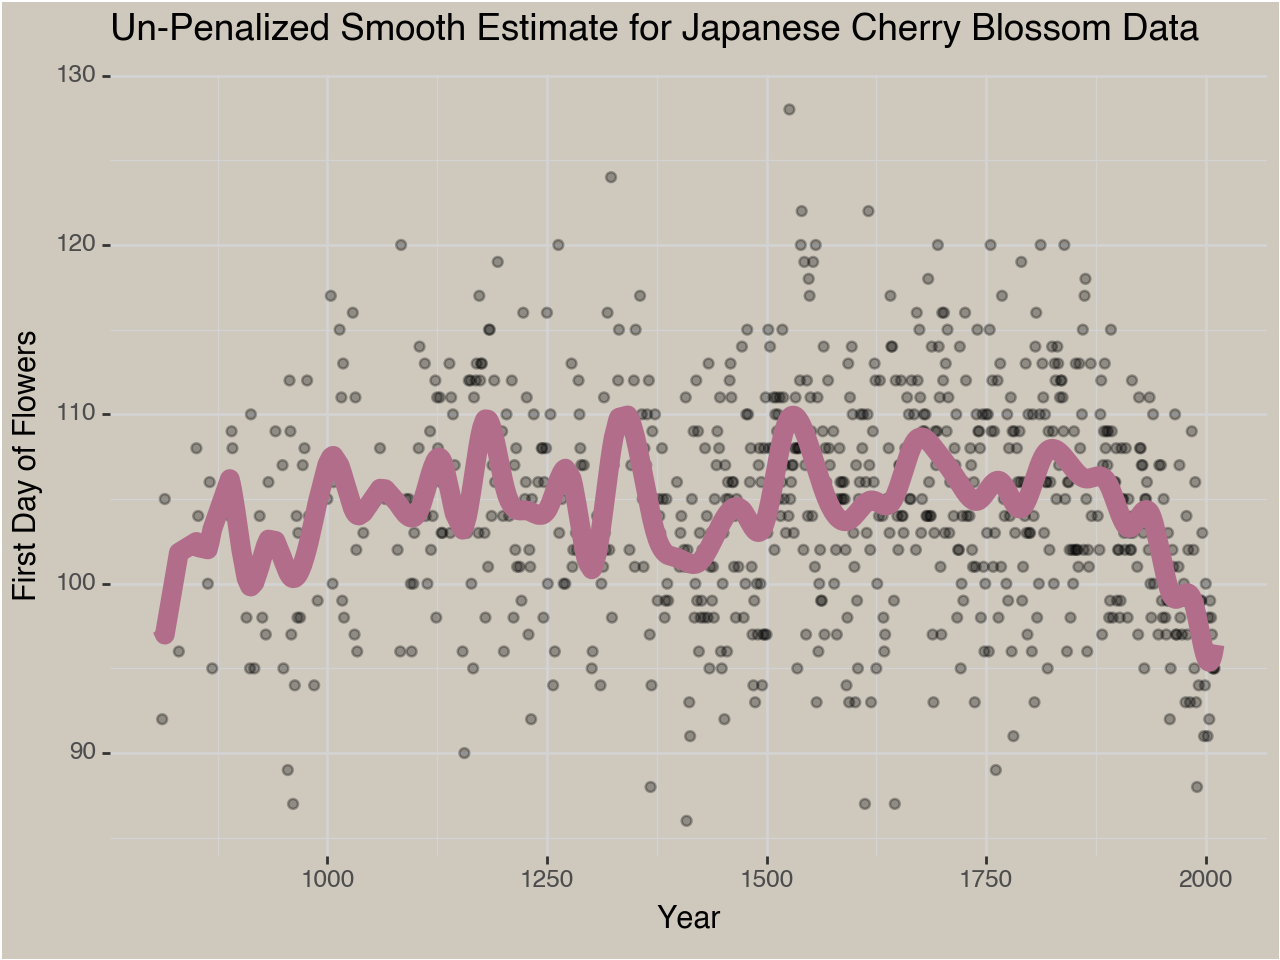

<Figure Size: (640 x 480)>

In [9]:
from collections import namedtuple

color_key = namedtuple('Colors', ['cherry', 'background'])
Colors = color_key(cherry='#B26D8B', background='#CEC8BD')

def cherry_theme(*args, **kwargs):
    return theme(plot_background=element_rect(fill=Colors.background),
                 panel_background=element_rect(fill=Colors.background),
                 legend_background=element_rect(fill=Colors.background),
                 panel_grid=element_line(color='lightgrey'),
                 axis_text=element_text(face='bold'),
                 *args, **kwargs)

(ggplot(flower_df_clean.to_pandas(), aes(x='year')) +
 geom_point(aes(y=f'{DV}*30'), alpha=0.3) +
 #geom_line(aes(y='base_preds'), group=1, color='white', size=5) +
 geom_line(aes(y='base_preds*30'), group=1, color=Colors.cherry, size=4) +
 xlab('Year') +
 ylab('First Day of Flowers') +
 ggtitle('Un-Penalized Smooth Estimate for Japanese Cherry Blossom Data') +
 cherry_theme()
)

In [ ]:
#| echo: True
def generate_constraint_matrix(coefs, direction='dec'):
    '''Generate a constraint matrix for a monotonic function. 
    
    I was debugging for a while so I did this super inneficiently to make sure I was doing it right
    '''
    con = np.zeros((len(coefs), len(coefs)))

    if direction=='inc':
        for i in range(len(coefs)):
            for j in range(len(coefs)):
                if i >= j:
                    con[i, j] = 1
    if direction=='dec':
        for i in range(len(coefs)):
            for j in range(len(coefs)):
                if i >= j:
                    con[i, j] = -1
        
        con[:, 0] = 1
    
    return con

cons_matrix = generate_constraint_matrix(base_model.coef_)
cons_matrix[:5, :5]

array([[ 1.,  0.,  0.,  0.,  0.],
       [ 1., -1.,  0.,  0.,  0.],
       [ 1., -1., -1.,  0.,  0.],
       [ 1., -1., -1., -1.,  0.],
       [ 1., -1., -1., -1., -1.]])

In [48]:
#| echo: True
def apply_shape_constraint(coef_b, direction='dec'):
    """
    Applies shape constraints to the coefficient vector, excluding the intercept.
    coef_b: shape-constrained coefficients (excluding intercept).
    direction: 'inc' for increasing, 'dec' for decreasing.
    """
    beta_exp = jnp.exp(coef_b)  # Ensure monotonicity
    cumulative_sums = jnp.array(generate_constraint_matrix(coef_b, direction))
    constrained_coefs = jnp.matmul(cumulative_sums, beta_exp.T)
    return constrained_coefs

test_coefs = np.random.uniform(size=5)
mono_coefs = apply_shape_constraint(test_coefs)
print(f'Latent Coefficients: {np.round(test_coefs, 2)}\n')
print(f'Constrained Coefficients: {np.round(mono_coefs, 2)}')

Latent Coefficients: [0.81 0.08 0.37 0.3  0.17]

Constrained Coefficients: [ 2.24  1.16 -0.29 -1.64 -2.83]


### Fiting a Model with JAX

Previously I used the excellent `glum` package to fit a GAM using a penalty matrix. We can't use that approach for SCAMs though because the constraint is enforced at the model matrix level, not an additional penalty matrix. I thought this would be a great chance to use JAX. JAX is a "numpy + autodif" library in python that many advanced Deep Learning models are built with these days. The reason we would use JAX to fit our model is that JAX will calculate a derivative of a function automatically. So all we need to do is write a loss function that accepts our input, unconstrained parameters and JAX will automatically calculate 1st and 2nd order gradients that we can pass to scipy's optimization function `minimize`. I'll write a helper function to get the predictions and then write functions to calculate our loss function, gradients, and hessians. 

In [ ]:
#| echo: True
def predict_mono_bspline(coefs, X=yearly_spline, direction='dec'):
    """
    Predicts values from a monotonic B-spline model without an intercept.
    coefs: full coefficient vector
    X: basis spline matrix.
    direction: 'inc' for increasing, 'dec' for decreasing.
    """
    #intercept = coefs[jnp.array([0])]  # Extract intercept
    #coef_b = coefs[1:]  # Shape-constrained coefficients
    coef_b = coefs  # Shape-constrained coefficients
    
    # Apply the shape constraint only to coef_b
    constrained_coefs = apply_shape_constraint(coef_b, direction)
    #model_coefs = jnp.concat([intercept, constrained_coefs])
    model_coefs = constrained_coefs
    
    # Compute predictions and add back the intercept
    preds = jnp.dot(X, model_coefs)
    return preds

def calc_loss(coefs, X=yearly_spline, y=flower_df_clean['flower_moy'].to_numpy()):
    preds = predict_mono_bspline(coefs, X)
    loss = jnp.mean(jnp.power(y - preds, 2))
    return loss


loss_grad = jax.grad(calc_loss)
loss_hess = jax.hessian(calc_loss)

In [ ]:
#| echo: True
coefs = base_model.coef_

gs = loss_grad(coefs)
hs = loss_hess(coefs)

result = minimize(
    fun=calc_loss,
    x0=np.array(coefs),  # SciPy requires NumPy
    jac=loss_grad,  # First derivative
    hess=loss_hess,  # Second derivative (optional, speeds up convergence)
    method="Newton-CG",
    options={"disp": True}
)

Optimization terminated successfully.
         Current function value: 0.042299
         Iterations: 101
         Function evaluations: 154
         Gradient evaluations: 154
         Hessian evaluations: 101


In [20]:
fit_coefs = result.x

mono_preds = predict_mono_bspline(fit_coefs)
flower_df_clean = flower_df_clean.with_columns(mono_preds = np.asarray(mono_preds))

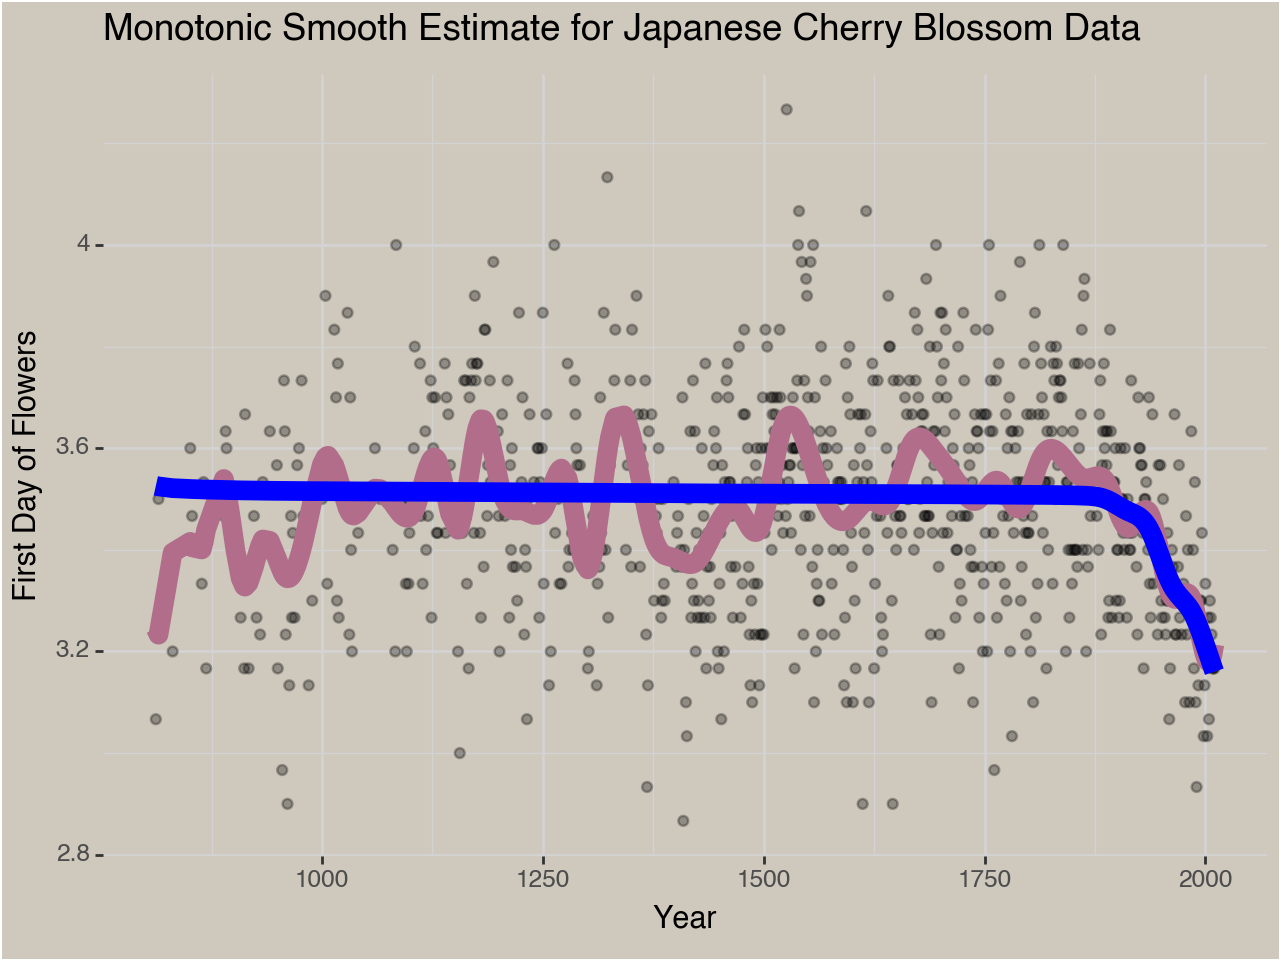

<Figure Size: (640 x 480)>

In [32]:
(ggplot(flower_df_clean.to_pandas(),aes(x='year')) +
 geom_point(aes(y=DV), alpha=0.3) +
 #geom_line(aes(y='base_preds'), group=1, color='white', size=5) +
 geom_line(aes(y='base_preds'), group=1, color=Colors.cherry, size=4) +
 geom_line(aes(y='mono_preds'), group=1, color='blue', size=4) +
 xlab('Year') +
 ylab('First Day of Flowers') +
 ggtitle('Monotonic Smooth Estimate for Japanese Cherry Blossom Data') +
#  annotate('label', x = 1875, y = 3.05, label = 'Monotonic', color = 'blue', size=14) +
#  annotate('label', x = 1875, y = 3.8, label = 'Unconstrained', color = Colors.cherry, size=14) +
 cherry_theme()
)

We can zoom in on the parts of the trend that actually decrease to see the difference in the relevant time period more clearly. 

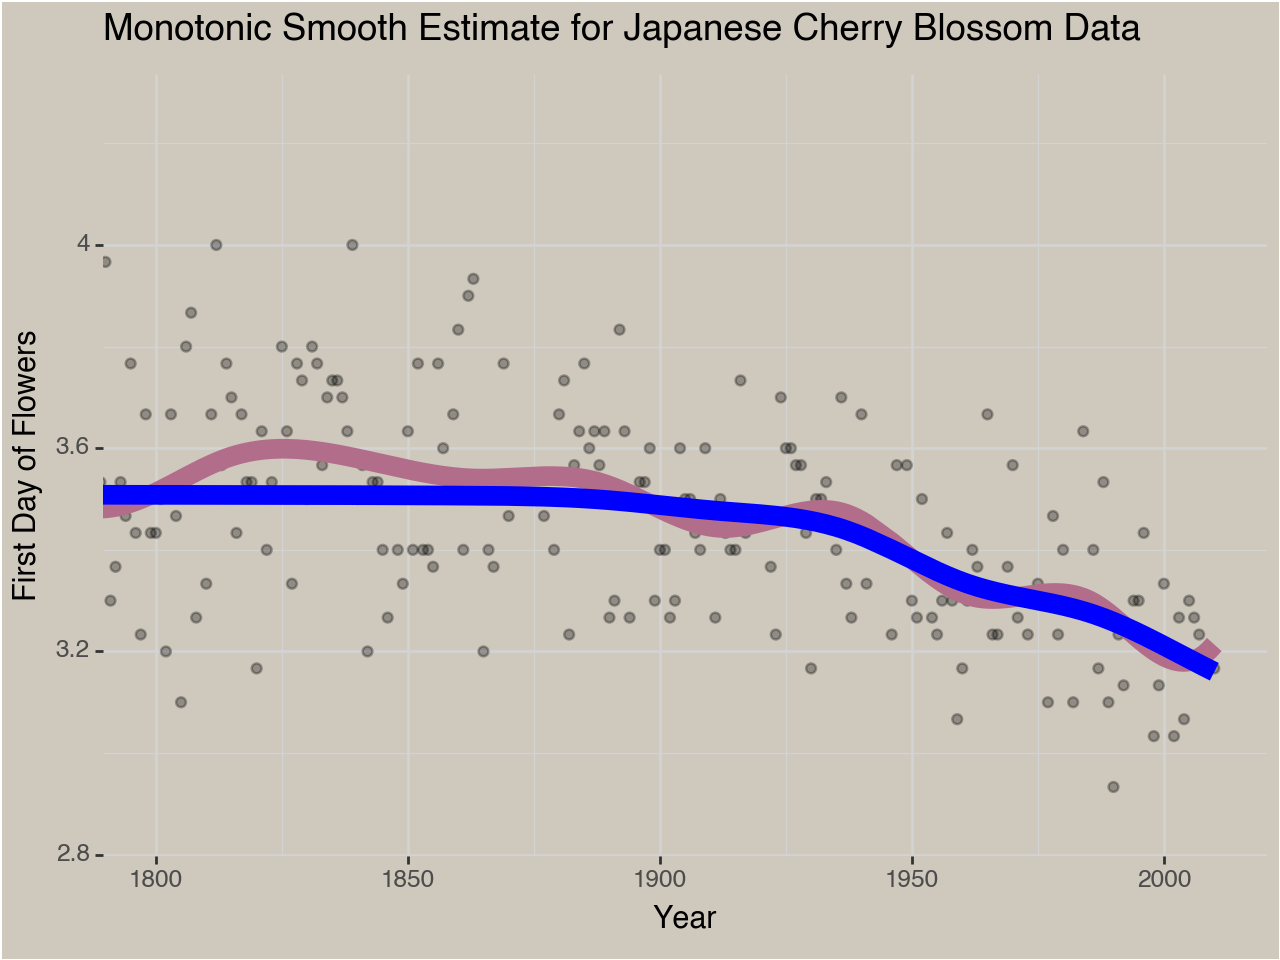

<Figure Size: (640 x 480)>

In [34]:
(ggplot(flower_df_clean.to_pandas(),aes(x='year')) +
 geom_point(aes(y=DV), alpha=0.3) +
 #geom_line(aes(y='base_preds'), group=1, color='white', size=5) +
 geom_line(aes(y='base_preds'), group=1, color=Colors.cherry, size=4) +
 geom_line(aes(y='mono_preds'), group=1, color='blue', size=4) +
 xlab('Year') +
 ylab('First Day of Flowers') +
 ggtitle('Monotonic Smooth Estimate for Japanese Cherry Blossom Data') + 
 cherry_theme() +
 coord_cartesian(xlim=(1800, 2010))
)